# Separatrix Primitives - 3 Robots and the Jacobian

Jacobian and determinant slope work on 4 robots.

correction direction is broken.

### Import Relevant Libraries

In [415]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg

#### Creating the Vector Field

In [416]:
class VectorField:
    """Class for creating and evaluating vector fields with critical points."""
    
    def __init__(self, field_type='two_vortices'):
        self.field_type = field_type
        
    def evaluate(self, x, y):
        """Evaluate the vector field at position (x, y)."""
        if self.field_type == 'two_vortices':
            # Two co-rotating vortices with a separatrix
            # Left vortex (counterclockwise)
            x1, y1 = -1, 0
            vx1 = -(y - y1)
            vy1 = (x - x1)
            
            # Right vortex (clockwise)
            x2, y2 = 1, 0
            vx2 = (y - y2)
            vy2 = -(x - x2)

            # Combine vector fields with distance-based weighting
            d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
            d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
            w1 = 1.0 / (d1**2 + 0.1)
            w2 = 1.0 / (d2**2 + 0.1)
            vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
            vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
            return np.array([vx, vy])
        elif self.field_type == 'saddle':
            # Simple saddle point at origin
            return np.array([x, -y])
        else:
            # Default: simple saddle point
            return np.array([x, -y])

### Creating the Robot Cluster


The primitive (update mechanism) is part of the cluster itself

In [417]:
class RobotCluster:
    """Class for managing a cluster of robots for vector field navigation."""
    
    def __init__(self, num_robots=3, formation_radius=0.1):
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        # Initialize robots in an equilateral triangle formation
        angles = np.linspace(0, 2*np.pi, num_robots, endpoint=False)
        self.positions = np.zeros((num_robots, 2))
        
        # Set initial centroid
        self.centroid = np.array([-0.13, 1.2])                                                                       # Centroid starts here
        
        # Position robots around the centroid
        for i in range(num_robots):
            self.positions[i] = self.centroid + formation_radius * np.array([np.cos(angles[i]), np.sin(angles[i])])
        
        # Store vector field readings at robot positions
        self.vector_readings = np.zeros((num_robots, 2))
        
    def update_readings(self, vector_field):
        """Update the vector field readings at each robot's position."""
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    
    def compute_jacobian(self):
        """
        Compute the Jacobian matrix of the vector field using the robot positions and readings.
        Uses Approach 1 from the document: solving for the critical point directly.
        """
        # Get positions and readings
        x1, y1 = self.positions[0]
        x2, y2 = self.positions[1]
        x3, y3 = self.positions[2]
        u1, v1 = self.vector_readings[0]
        u2, v2 = self.vector_readings[1]
        u3, v3 = self.vector_readings[2]
        
        # Set up the system of equations for u component (ax + by + c = u)
        A_u = np.array([
            [x1, y1, 1],
            [x2, y2, 1],
            [x3, y3, 1]
        ])
        b_u = np.array([u1, u2, u3])
        
        # Set up the system of equations for v component (dx + ey + f = v)
        A_v = A_u.copy()  # Same matrix for both systems
        b_v = np.array([v1, v2, v3])
        
        # Solve the systems
        try:
            a, b, c = np.linalg.solve(A_u, b_u)
            d, e, f = np.linalg.solve(A_v, b_v)
            
            # The Jacobian matrix
            J = np.array([
                [a, b],
                [d, e]
            ])
            
            # Compute the estimated critical point
            critical_matrix = np.array([
                [a, b],
                [d, e]
            ])
            critical_vector = np.array([-c, -f])
            
            try:
                critical_point = np.linalg.solve(critical_matrix, critical_vector)
                return J, critical_point
            except np.linalg.LinAlgError:
                # If the matrix is singular, return the Jacobian but no critical point
                return J, None
            
        except np.linalg.LinAlgError:
            # If the system can't be solved (e.g., collinear robots), return None
            return None, None
    
        
        # Fallback if no clear separatrix detected
        return None, None
    
    def update_positions(self, delta):
        """Update the positions of all robots based on a delta movement of the centroid."""
        old_centroid = self.centroid.copy()
        self.centroid += delta
        
        # Maintain the formation shape around the new centroid
        formation_vectors = self.positions - np.tile(old_centroid, (self.num_robots, 1))  # Use old_centroid
        self.positions = np.tile(self.centroid, (self.num_robots, 1)) + formation_vectors

### Visualization

In [418]:
def visualize_results(centroid_history, critical_points_history, eigenvector_history, robots, plot_field=True):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Set limits
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2, 8)
    
    # Plot the vector field
    if plot_field:
        x = np.linspace(-5, 5, 20)
        y = np.linspace(-2, 8, 20)
        X, Y = np.meshgrid(x, y)
        
        vf = VectorField(field_type='two_vortices')
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(U**2 + V**2)
        U = U / magnitude
        V = V / magnitude
        
        ax.quiver(X, Y, U, V, alpha=0.3, color='gray')
    
    # Plot critical points
    if critical_points_history:
        critical_points = np.array(critical_points_history)
        ax.scatter(critical_points[:, 0], critical_points[:, 1], c='red', marker='x', s=100, label='Estimated Critical Points')
    
    # Plot eigenvectors at certain positions
    for pos, eigvec in eigenvector_history[::10]:  # Plot every 10th eigenvector
        ax.arrow(pos[0], pos[1], eigvec[0]*0.2, eigvec[1]*0.2, head_width=0.05, head_length=0.08, fc='green', ec='green', alpha=0.5)
    
    # Plot robot positions at final step
    for i, pos in enumerate(robots.positions):
        ax.scatter(pos[0], pos[1], c='blue', marker='o', s=100)
        circle = Circle(pos, 0.05, fill=False, color='blue')
        ax.add_patch(circle)
        ax.text(pos[0]+0.05, pos[1]+0.05, f'Robot {i+1}')
    
    # Plot centroid path
    ax.plot(centroid_history[:, 0], centroid_history[:, 1], 'b-', alpha=0.7, label='Cluster Centroid Path')
    ax.scatter(centroid_history[0, 0], centroid_history[0, 1], c='green', marker='o', s=100, label='Start')
    ax.scatter(centroid_history[-1, 0], centroid_history[-1, 1], c='red', marker='o', s=100, label='End')
    
    # Labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('3-Robot Cluster Following Separatrix in Vector Field')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    return fig

### Main

Looks like the default behaviour is a special case.

The fall back to the Jacobian case should be main.
The superfallback to average should be the fall back, and explictly called out.
Does that mean I can remove def detect_separatrix_direction(self): altogether?

Using Jacobian Method
[0.92933831 0.02752021]
[[ 0.98733948 -0.0192532 ]
 [ 0.15862142  0.99981464]]
Using Jacobian Method
[0.9286595  0.02710258]
[[ 0.9875056  -0.02054263]
 [ 0.15758394  0.99978898]]
Using Jacobian Method
[0.92791553 0.0266959 ]
[[ 0.9876643  -0.02179876]
 [ 0.15658617  0.99976238]]
Using Jacobian Method
[0.92710862 0.02629974]
[[ 0.98781597 -0.02302274]
 [ 0.15562652  0.99973494]]
Using Jacobian Method
[0.92624093 0.02591368]
[[ 0.98796095 -0.02421568]
 [ 0.15470349  0.99970676]]
Using Jacobian Method
[0.92531456 0.02553731]
[[ 0.98809957 -0.02537861]
 [ 0.15381562  0.99967791]]
Using Jacobian Method
[0.92433153 0.02517026]
[[ 0.98823214 -0.02651256]
 [ 0.15296155  0.99964848]]
Using Jacobian Method
[0.92329384 0.02481217]
[[ 0.98835896 -0.02761849]
 [ 0.15213996  0.99961854]]
Using Jacobian Method
[0.92220338 0.0244627 ]
[[ 0.9884803  -0.02869732]
 [ 0.15134961  0.99958815]]
Using Jacobian Method
[0.92106203 0.02412153]
[[ 0.98859641 -0.02974993]
 [ 0.15058929  0.9

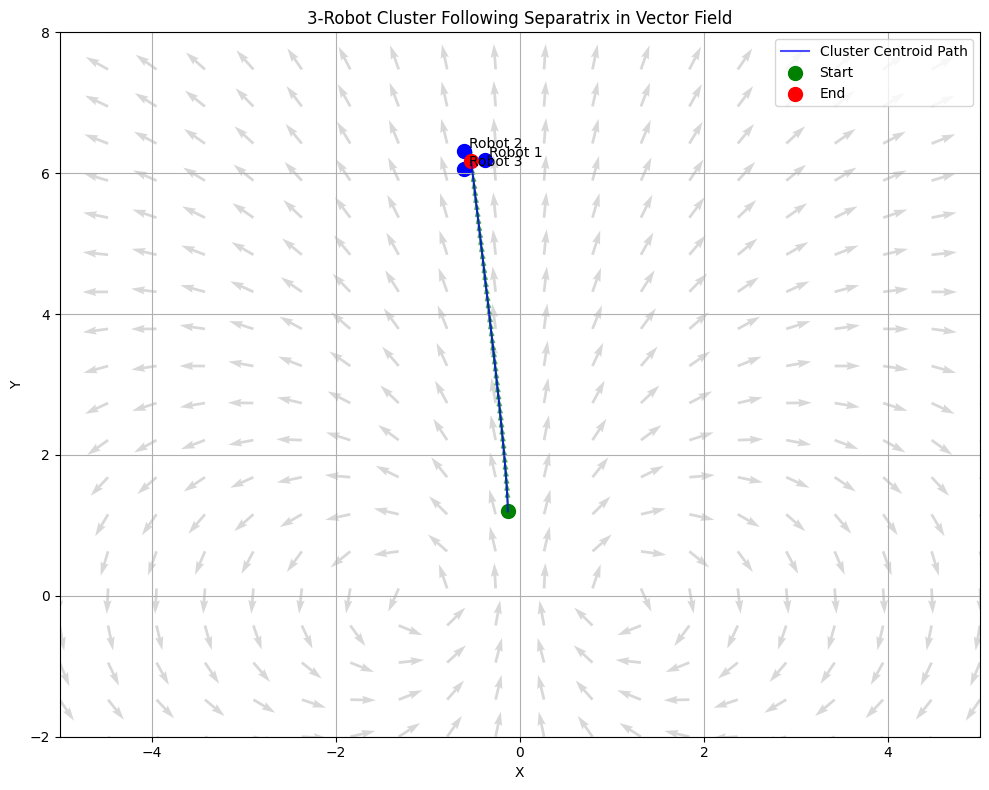

In [419]:

def simulate_separatrix_following():
    
    # Create a vector field
    vector_field = VectorField(field_type='two_vortices')
    
    # Create a robot cluster
    robots = RobotCluster(num_robots=3, formation_radius=0.15)
    
    # Time steps for simulation
    n_steps = 500
    
    # Arrays to store data for plotting
    centroid_history = np.zeros((n_steps, 2))
    critical_points_history = []
    eigenvector_history = []
    
    # Simulation loop
    for step in range(n_steps):

        # Store centroid history
        centroid_history[step] = robots.centroid
        
        # Update vector field readings at robot positions
        robots.update_readings(vector_field)
        
        # Compute Jacobian    
        J, critical_point = robots.compute_jacobian()
        
        if J is not None:
            print('Using Jacobian Method')
            
            # Get eigenvalues and eigenvectors
            eigvals, eigvecs = np.linalg.eig(J)
            print(eigvals)
            print(eigvecs)

            
            # Get average flow at centroid
            actual_flow = np.mean(robots.vector_readings, axis=0)
            actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
            
            # Choose eigenvector that best aligns with flow
            eigvec1 = np.real(eigvecs[:, 0])
            eigvec2 = np.real(eigvecs[:, 1])
            eigvec1 = eigvec1 / np.linalg.norm(eigvec1)
            eigvec2 = eigvec2 / np.linalg.norm(eigvec2)
            
            dot1 = abs(np.dot(actual_flow_norm, eigvec1))
            dot2 = abs(np.dot(actual_flow_norm, eigvec2))
            
            if dot1 > dot2:
                primary_eigvec = eigvec1
                secondary_eigvec = eigvec2
                primary_eigval = eigvals[0]
            else:
                primary_eigvec = eigvec2
                secondary_eigvec = eigvec1
                primary_eigval = eigvals[1]
            
            # Ensure direction consistency
            if np.dot(primary_eigvec, actual_flow_norm) < 0:
                primary_eigvec = -primary_eigvec
            
            direction = primary_eigvec
            
            # Store for visualization
            eigenvector_history.append((robots.centroid.copy(), primary_eigvec.copy()))
            
        else:
            # Fallback: use average vector field
            print('Super fall back to using average direction')
            avg_vector = np.mean(robots.vector_readings, axis=0)
            avg_vector_norm = np.linalg.norm(avg_vector)
            if avg_vector_norm > 0:
                direction = avg_vector / avg_vector_norm
            else:
                direction = np.array([0, 1])  # Default upward
        
        # Update position
        step_size = 0.01
        robots.update_positions(step_size * direction)
    
    return centroid_history, critical_points_history, eigenvector_history, robots

if __name__ == "__main__":
    # Run the simulation
    centroid_history, critical_points_history, eigenvector_history, robots = simulate_separatrix_following()
    
    # Visualize the results
    fig = visualize_results(centroid_history, critical_points_history, eigenvector_history, robots)
    plt.show()

# 4 Robot Version

## Import Libraries

In [420]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg

## Create the Field

In [421]:
class VectorField:
    """Class for creating and evaluating vector fields with critical points."""
    
    def __init__(self, field_type='two_vortices'):
        self.field_type = field_type
        
    def evaluate(self, x, y):
        """Evaluate the vector field at position (x, y)."""
        if self.field_type == 'two_vortices':
            # Two co-rotating vortices with a separatrix
            # Left vortex (counterclockwise)
            x1, y1 = -1, 0
            vx1 = -(y - y1)
            vy1 = (x - x1)
            
            # Right vortex (clockwise)
            x2, y2 = 1, 0
            vx2 = (y - y2)
            vy2 = -(x - x2)

            # Combine vector fields with distance-based weighting
            d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
            d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
            w1 = 1.0 / (d1**2 + 0.1)
            w2 = 1.0 / (d2**2 + 0.1)
            vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
            vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
            return np.array([vx, vy])
        elif self.field_type == 'saddle':
            # Simple saddle point at origin
            return np.array([x, -y])
        else:
            # Default: simple saddle point
            return np.array([x, -y])

## Create the Robot Cluster

In [422]:
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

class RobotCluster4:
    """Class for managing a cluster of robots for vector field navigation."""
    
    def __init__(self, num_robots=4, formation_radius=0.3):                                                                 # INITIALIZATION
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        
        
        # Initialize robots in an equilateral shape
        angles = np.linspace(0, 2*np.pi, num_robots, endpoint=False)
        random_offset = np.random.uniform(0, np.pi/2)
        angles = angles + random_offset
        
        self.positions = np.zeros((num_robots, 2))
        
        # Set initial centroid
        self.centroid = np.array([1.05, 1.2])                                                                             # Centroid starts here
        
        # Position robots around the centroid
        for i in range(num_robots):
            self.positions[i] = self.centroid + formation_radius * np.array([np.cos(angles[i]), np.sin(angles[i])])
        
        # Store vector field readings at robot positions
        self.vector_readings = np.zeros((num_robots, 2))
        
    def update_readings(self, vector_field):
        """Update the vector field readings at each robot's position."""
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    

    def compute_jacobian(self):
        """
        Compute the Jacobian matrix using least squares with all 4 robots.
        """
        # Set up overdetermined system
        A = np.column_stack([self.positions[:, 0], self.positions[:, 1], np.ones(4)])
        b_u = self.vector_readings[:, 0]
        b_v = self.vector_readings[:, 1]
        
        try:
            # Least squares solution
            coeffs_u, _, _, _ = np.linalg.lstsq(A, b_u, rcond=None)
            coeffs_v, _, _, _ = np.linalg.lstsq(A, b_v, rcond=None)
            
            # Extract Jacobian
            J = np.array([
                [coeffs_u[0], coeffs_u[1]],
                [coeffs_v[0], coeffs_v[1]]
            ])
            
            #print('Jacobian fu,', J)
            return J, None
            
        except np.linalg.LinAlgError:
            print('Jacobian unable to be determined')
            return None, None
        

    def compute_determinant_gradient(self):
        """
        Compute the gradient of det(J) using 4 robots and 4 choose 3 combinations.
        Returns the direction pointing toward det(J) = 0.
        """
        
        
        # First, get the current determinant at the centroid using all 4 robots
        J_current, _ = self.compute_jacobian()
        if J_current is None:
            return np.array([0.0, 0.0])
    
        det_current = np.linalg.det(J_current)
        print('Current Determinant', det_current)
        
        
        
        # Get all combinations of 3 robots from 4
        robot_combinations = list(combinations(range(4), 3))
        
        jacobians = []
        determinants = []
        centroids = []
        
        # Calculate Jacobian for each 3-robot combination
        for combo in robot_combinations:
            pos_subset = self.positions[list(combo)]
            readings_subset = self.vector_readings[list(combo)]
            
            # Calculate centroid for this combination
            centroid = np.mean(pos_subset, axis=0)
            
            # Compute Jacobian using the 3 robots
            x1, y1 = pos_subset[0]
            x2, y2 = pos_subset[1]
            x3, y3 = pos_subset[2]
            u1, v1 = readings_subset[0]
            u2, v2 = readings_subset[1]
            u3, v3 = readings_subset[2]
            
            # Set up the system of equations
            A = np.array([
                [x1, y1, 1],
                [x2, y2, 1],
                [x3, y3, 1]
            ])
            b_u = np.array([u1, u2, u3])
            b_v = np.array([v1, v2, v3])
            
            try:
                # Solve for coefficients
                a, b, c = np.linalg.solve(A, b_u)
                d, e, f = np.linalg.solve(A, b_v)
                
                # Construct Jacobian
                J = np.array([[a, b], [d, e]])
                
                # Compute determinant
                det_J = np.linalg.det(J)
                
                jacobians.append(J)
                determinants.append(det_J)
                centroids.append(centroid)
                
            except np.linalg.LinAlgError:
                # Skip this combination if singular
                continue
        
        if len(centroids) < 4:
            print(f"Warning: Only {len(centroids)} valid Jacobians computed")
            return np.array([0.0, 0.0])  # Return zero correction if insufficient data
        
        # Convert to numpy arrays
        centroids = np.array(centroids)
        determinants = np.array(determinants)
        print('determinants', determinants)
        # Now fit a plane to the 4 points (x, y, det(J))
        # We want to find the gradient of det(J) with respect to (x, y)
        # Set up overdetermined system: ax + by + c = det(J)
        A_grad = np.column_stack([centroids[:, 0], centroids[:, 1], np.ones(len(centroids))])
        
        try:
            # Least squares solution
            coeffs, _, _, _ = np.linalg.lstsq(A_grad, determinants, rcond=None)
            grad_x = coeffs[0]  # ∂det(J)/∂x
            grad_y = coeffs[1]  # ∂det(J)/∂y
            
            # Gradient vector
            gradient = np.array([grad_x, grad_y])
            print('gradient of determinant', gradient)
            
            # Direction pointing toward det(J) = 0 is negative gradient
            if np.linalg.norm(gradient) > 1e-10:
                correction_direction = -np.sign(det_current) * gradient
                correction_direction = correction_direction / np.linalg.norm(correction_direction)
            else:
                correction_direction = np.array([0.0, 0.0])
                
            # Store debug info
            self.debug_info = {
                'centroids': centroids,
                'determinants': determinants,
                'gradient': gradient,
                'correction_direction': correction_direction
            }
            
            return correction_direction
            
        except np.linalg.LinAlgError:
            print("Warning: Could not compute determinant gradient")
            return np.array([0.0, 0.0])

    
    def update_positions(self, delta):
        """Update the positions of all robots based on a delta movement of the centroid."""
        old_centroid = self.centroid.copy()
        self.centroid += delta
        
        # Maintain the formation shape around the new centroid
        formation_vectors = self.positions - np.tile(old_centroid, (self.num_robots, 1))  # Use old_centroid
        self.positions = np.tile(self.centroid, (self.num_robots, 1)) + formation_vectors

## Vizualization

In [423]:
def visualize_results(centroid_history, critical_points_history, eigenvector_history, robots, plot_field=True):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Set limits
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2, 8)
    
    # Plot the vector field
    if plot_field:
        x = np.linspace(-5, 5, 20)
        y = np.linspace(-2, 8, 20)
        X, Y = np.meshgrid(x, y)
        
        vf = VectorField(field_type='two_vortices')
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(U**2 + V**2)
        U = U / magnitude
        V = V / magnitude
        
        ax.quiver(X, Y, U, V, alpha=0.3, color='gray')
    
    # Plot critical points
    if critical_points_history:
        critical_points = np.array(critical_points_history)
        ax.scatter(critical_points[:, 0], critical_points[:, 1], c='red', marker='x', s=100, label='Estimated Critical Points')
    
    # Plot eigenvectors at certain positions
    for pos, eigvec in eigenvector_history[::10]:  # Plot every 10th eigenvector
        ax.arrow(pos[0], pos[1], eigvec[0]*0.2, eigvec[1]*0.2, head_width=0.05, head_length=0.08, fc='green', ec='green', alpha=0.5)
    
    # Plot robot positions at final step
    for i, pos in enumerate(robots.positions):
        ax.scatter(pos[0], pos[1], c='blue', marker='o', s=100)
        circle = Circle(pos, 0.05, fill=False, color='blue')
        ax.add_patch(circle)
        ax.text(pos[0]+0.05, pos[1]+0.05, f'Robot {i+1}')
    
    # Plot centroid path
    ax.plot(centroid_history[:, 0], centroid_history[:, 1], 'b-', alpha=0.7, label='Cluster Centroid Path')
    ax.scatter(centroid_history[0, 0], centroid_history[0, 1], c='green', marker='o', s=100, label='Start')
    ax.scatter(centroid_history[-1, 0], centroid_history[-1, 1], c='red', marker='o', s=100, label='End')
    
    # Labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('4-Robot Cluster Following Separatrix in Vector Field')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    return fig

## Main

Current Determinant 0.20175413602027434
determinants [0.1544887  0.26612034 0.24901957 0.13738793]
gradient of determinant [0.95525523 0.07602472]
Correction direction [-0.99684802 -0.07933491]

print debugging
Primary eigenvector   [0.07994729 0.99679909]
correction direction  [-0.99684802 -0.07933491]
direction             [0.06997881 0.99600574]

Current Determinant 0.1979496280827636
determinants [0.15107294 0.26197394 0.24482632 0.13392531]
gradient of determinant [0.94910071 0.07687089]
Correction direction [-0.99673608 -0.08072904]

print debugging
Primary eigenvector   [0.07773799 0.99697382]
correction direction  [-0.99673608 -0.08072904]
direction             [0.06777063 0.99616653]

Current Determinant 0.19421256573420687
determinants [0.14772437 0.25788775 0.24070077 0.13053738]
gradient of determinant [0.94288254 0.0776579 ]
Correction direction [-0.99662539 -0.08208429]

print debugging
Primary eigenvector   [0.07549408 0.99714625]
correction direction  [-0.99662539 -0.08

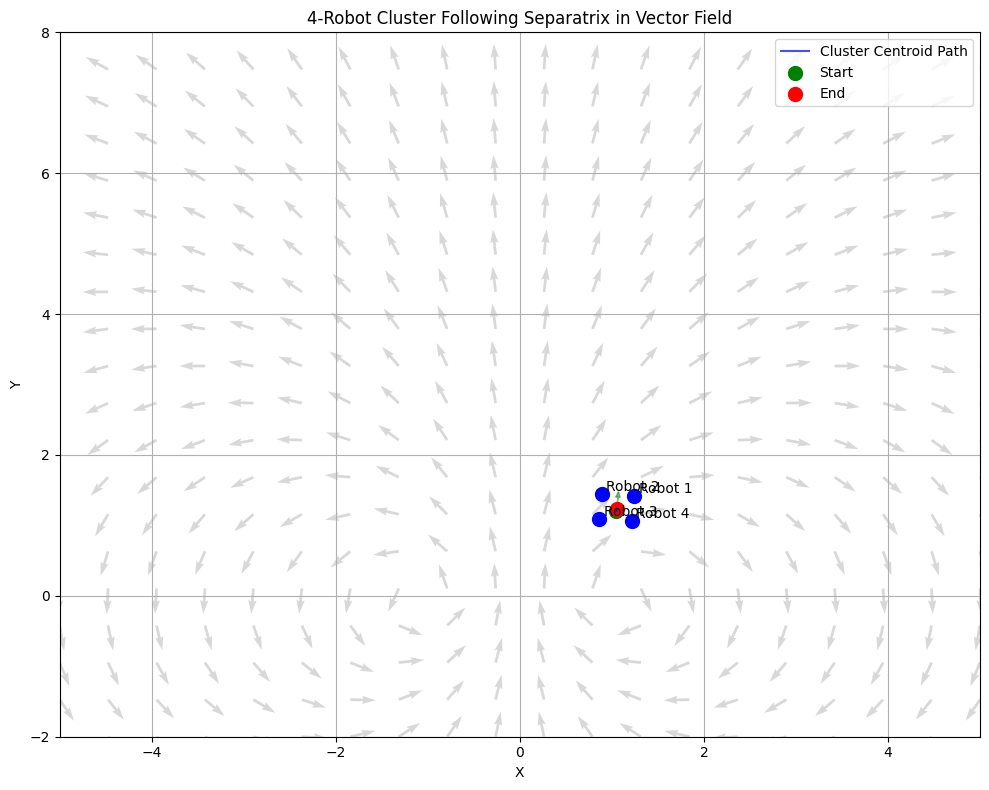

In [449]:

def simulate_separatrix_following():
    
    # Create a vector field
    vector_field = VectorField(field_type='two_vortices')
    
    # Create a robot cluster
    robots = RobotCluster4(num_robots=4, formation_radius=0.25)
    
    # Time steps for simulation
    n_steps = 5
    
    # Arrays to store data for plotting
    centroid_history = np.zeros((n_steps, 2))
    critical_points_history = []
    eigenvector_history = []
    
    # Simulation loop
    for step in range(n_steps):

        # Store centroid history
        centroid_history[step] = robots.centroid
        
        # Update vector field readings at robot positions
        robots.update_readings(vector_field)
        
        # Compute Jacobian    
        correction_direction = robots.compute_determinant_gradient()
        print('Correction direction', correction_direction)
        J, critical_point = robots.compute_jacobian()
        
        if J is not None:
            #print('Using Jacobian Method')
            
            # Get eigenvalues and eigenvectors
            eigvals, eigvecs = np.linalg.eig(J)
            
            # Get average flow at centroid
            actual_flow = np.mean(robots.vector_readings, axis=0)
            actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
            
            # Choose eigenvector that best aligns with flow
            eigvec1 = np.real(eigvecs[:, 0])
            eigvec2 = np.real(eigvecs[:, 1])
            eigvec1 = eigvec1 / np.linalg.norm(eigvec1)
            eigvec2 = eigvec2 / np.linalg.norm(eigvec2)
            
            dot1 = abs(np.dot(actual_flow_norm, eigvec1))
            dot2 = abs(np.dot(actual_flow_norm, eigvec2))
            
            if dot1 > dot2:
                primary_eigvec = eigvec1
                secondary_eigvec = eigvec2
                primary_eigval = eigvals[0]
            else:
                primary_eigvec = eigvec2
                secondary_eigvec = eigvec1
                primary_eigval = eigvals[1]
            
            # Ensure direction consistency
            if np.dot(primary_eigvec, actual_flow_norm) < 0:
                primary_eigvec = -primary_eigvec
            
            
            
            direction = primary_eigvec + 0.01*correction_direction 
            
            print()
            print('print debugging')
            print('Primary eigenvector  ',primary_eigvec)
            print('correction direction ',correction_direction)
            print('direction            ',direction)
            print()
            # Store for visualization
            eigenvector_history.append((robots.centroid.copy(), primary_eigvec.copy()))
            
        else:
            # Fallback: use average vector field
            print('Super fall back to using average direction')
            avg_vector = np.mean(robots.vector_readings, axis=0)
            avg_vector_norm = np.linalg.norm(avg_vector)
            if avg_vector_norm > 0:
                direction = avg_vector / avg_vector_norm
            else:
                direction = np.array([0, 1])  # Default upward
        
        # Update position
        step_size = 0.01
        robots.update_positions(step_size * direction)
    
    return centroid_history, critical_points_history, eigenvector_history, robots

if __name__ == "__main__":
    # Run the simulation
    centroid_history, critical_points_history, eigenvector_history, robots = simulate_separatrix_following()
    
    # Visualize the results
    fig = visualize_results(centroid_history, critical_points_history, eigenvector_history, robots)
    plt.show()

## Field Visualization

Creating comprehensive visualization for two_vortices field...

=== Vector Field Analysis: Two Vortices ===
Determinant range: [0.000, 1.055]
Trace range: [-0.947, 0.947]
Most stable eigenvalue range: [-0.940, 0.417]
Potential critical points detected where |det| < 0.1


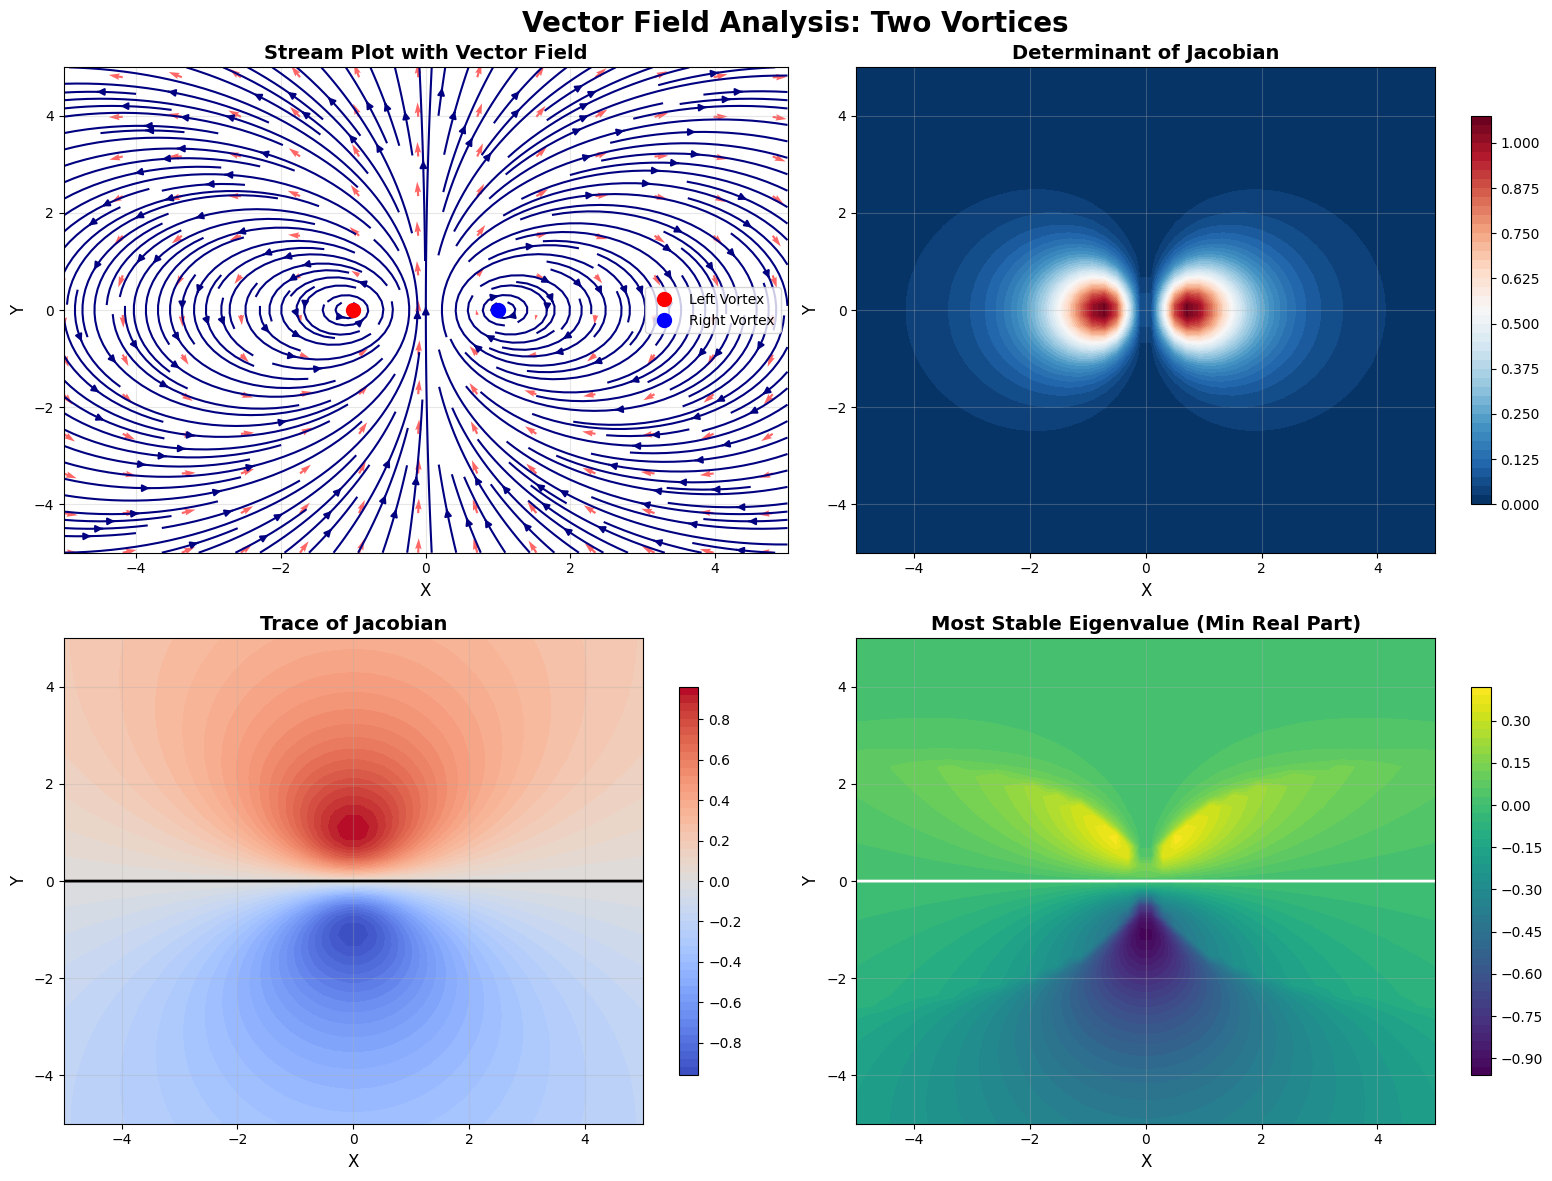

In [425]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg
import warnings
warnings.filterwarnings('ignore')

class VectorField:
    """Class for creating and evaluating vector fields with critical points."""
    
    def __init__(self, field_type='two_vortices'):
        self.field_type = field_type
        
    def evaluate(self, x, y):
        """Evaluate the vector field at position (x, y)."""
        if self.field_type == 'two_vortices':
            # Two co-rotating vortices with a separatrix
            # Left vortex (counterclockwise)
            x1, y1 = -1, 0
            vx1 = -(y - y1)
            vy1 = (x - x1)
            
            # Right vortex (clockwise)
            x2, y2 = 1, 0
            vx2 = (y - y2)
            vy2 = -(x - x2)

            # Combine vector fields with distance-based weighting
            d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
            d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
            w1 = 1.0 / (d1**2 + 0.1)
            w2 = 1.0 / (d2**2 + 0.1)
            vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
            vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
            return np.array([vx, vy])
        elif self.field_type == 'saddle':
            # Simple saddle point at origin
            return np.array([x, -y])
        else:
            # Default: simple saddle point
            return np.array([x, -y])
    
    def jacobian(self, x, y, h=0.001):
        """Compute numerical Jacobian using finite differences."""
        fx, fy = self.evaluate(x, y)
        fx_dx, fy_dx = self.evaluate(x + h, y)
        fx_dy, fy_dy = self.evaluate(x, y + h)
        
        J = np.array([
            [(fx_dx - fx) / h, (fx_dy - fx) / h],
            [(fy_dx - fy) / h, (fy_dy - fy) / h]
        ])
        return J

def compute_field_properties(vector_field, x_range=(-5, 5), y_range=(-5, 5), resolution=50):
    """Compute vector field, Jacobian properties over a grid."""
    x = np.linspace(x_range[0], x_range[1], resolution)
    y = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x, y)
    
    # Initialize arrays
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    determinant = np.zeros_like(X)
    trace = np.zeros_like(X)
    most_stable_eigenvalue = np.zeros_like(X)
    
    # Compute properties at each grid point
    for i in range(len(y)):
        for j in range(len(x)):
            # Vector field
            u, v = vector_field.evaluate(X[i, j], Y[i, j])
            U[i, j] = u
            V[i, j] = v
            
            # Jacobian and its properties
            try:
                J = vector_field.jacobian(X[i, j], Y[i, j])
                
                # Determinant and trace
                det = np.linalg.det(J)
                tr = np.trace(J)
                determinant[i, j] = det
                trace[i, j] = tr
                
                # Eigenvalues
                eigvals = np.linalg.eigvals(J)
                
                # Most stable eigenvalue (most negative real part)
                real_parts = np.real(eigvals)
                most_stable_eigenvalue[i, j] = np.min(real_parts)
                
            except:
                # Handle any numerical issues
                determinant[i, j] = np.nan
                trace[i, j] = np.nan
                most_stable_eigenvalue[i, j] = np.nan
    
    return X, Y, U, V, determinant, trace, most_stable_eigenvalue

def create_comprehensive_visualization(field_type='two_vortices', resolution=50):
    """Create a comprehensive 2x2 visualization of the vector field analysis."""
    
    # Create vector field
    vf = VectorField(field_type=field_type)
    
    # Compute properties
    X, Y, U, V, det, tr, most_stable_eig = compute_field_properties(vf, resolution=resolution)
    
    # Create figure with subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Vector Field Analysis: {field_type.replace("_", " ").title()}', 
                 fontsize=20, fontweight='bold', y=0.98)
    
    # 1. Stream Plot
    ax1.streamplot(X, Y, U, V, density=2, color='navy',  linewidth=1.5)
    ax1.quiver(X[::4, ::4], Y[::4, ::4], U[::4, ::4], V[::4, ::4], 
               alpha=0.6, scale=50, color='red', width=0.003)
    ax1.set_title('Stream Plot with Vector Field', fontsize=14, fontweight='bold')
    ax1.set_xlabel('X', fontsize=12)
    ax1.set_ylabel('Y', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Add vortex centers for two_vortices case
    if field_type == 'two_vortices':
        ax1.plot(-1, 0, 'ro', markersize=10, label='Left Vortex')
        ax1.plot(1, 0, 'bo', markersize=10, label='Right Vortex')
        ax1.legend()
    
    # 2. Determinant
    det_clean = np.where(np.isfinite(det), det, 0)
    im2 = ax2.contourf(X, Y, det_clean, levels=50, cmap='RdBu_r')
    ax2.contour(X, Y, det_clean, levels=[0], colors='black', linewidths=2)
    plt.colorbar(im2, ax=ax2, shrink=0.8)
    ax2.set_title('Determinant of Jacobian', fontsize=14, fontweight='bold')
    ax2.set_xlabel('X', fontsize=12)
    ax2.set_ylabel('Y', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 3. Trace
    tr_clean = np.where(np.isfinite(tr), tr, 0)
    im3 = ax3.contourf(X, Y, tr_clean, levels=50, cmap='coolwarm')
    ax3.contour(X, Y, tr_clean, levels=[0], colors='black', linewidths=2)
    plt.colorbar(im3, ax=ax3, shrink=0.8)
    ax3.set_title('Trace of Jacobian', fontsize=14, fontweight='bold')
    ax3.set_xlabel('X', fontsize=12)
    ax3.set_ylabel('Y', fontsize=12)
    ax3.grid(True, alpha=0.3)
    
    # 4. Most Stable Eigenvalue
    eig_clean = np.where(np.isfinite(most_stable_eig), most_stable_eig, 0)
    im4 = ax4.contourf(X, Y, eig_clean, levels=50, cmap='viridis')
    ax4.contour(X, Y, eig_clean, levels=[0], colors='white', linewidths=2)
    plt.colorbar(im4, ax=ax4, shrink=0.8)
    ax4.set_title('Most Stable Eigenvalue (Min Real Part)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('X', fontsize=12)
    ax4.set_ylabel('Y', fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print some statistics
    print(f"\n=== Vector Field Analysis: {field_type.replace('_', ' ').title()} ===")
    print(f"Determinant range: [{np.nanmin(det):.3f}, {np.nanmax(det):.3f}]")
    print(f"Trace range: [{np.nanmin(tr):.3f}, {np.nanmax(tr):.3f}]")
    print(f"Most stable eigenvalue range: [{np.nanmin(most_stable_eig):.3f}, {np.nanmax(most_stable_eig):.3f}]")
    
    # Find critical points (where determinant changes sign or is near zero)
    det_near_zero = np.abs(det_clean) < 0.1
    if np.any(det_near_zero):
        print("Potential critical points detected where |det| < 0.1")
    
    return fig

def compare_field_types():
    """Compare different field types side by side."""
    field_types = ['two_vortices', 'saddle']
    
    fig, axes = plt.subplots(len(field_types), 4, figsize=(20, 10))
    fig.suptitle('Comparison of Vector Field Types', fontsize=20, fontweight='bold')
    
    for i, field_type in enumerate(field_types):
        vf = VectorField(field_type=field_type)
        X, Y, U, V, det, tr, most_stable_eig = compute_field_properties(vf, resolution=40)
        
        # Stream plot
        axes[i, 0].streamplot(X, Y, U, V, density=1.5, color='navy', alpha=0.7)
        axes[i, 0].set_title(f'{field_type.replace("_", " ").title()}\nStream Plot')
        axes[i, 0].grid(True, alpha=0.3)
        
        # Determinant
        det_clean = np.where(np.isfinite(det), det, 0)
        im1 = axes[i, 1].contourf(X, Y, det_clean, levels=30, cmap='RdBu_r')
        axes[i, 1].contour(X, Y, det_clean, levels=[0], colors='black', linewidths=2)
        axes[i, 1].set_title('Determinant')
        axes[i, 1].grid(True, alpha=0.3)
        
        # Trace
        tr_clean = np.where(np.isfinite(tr), tr, 0)
        im2 = axes[i, 2].contourf(X, Y, tr_clean, levels=30, cmap='coolwarm')
        axes[i, 2].contour(X, Y, tr_clean, levels=[0], colors='black', linewidths=2)
        axes[i, 2].set_title('Trace')
        axes[i, 2].grid(True, alpha=0.3)
        
        # Most stable eigenvalue
        eig_clean = np.where(np.isfinite(most_stable_eig), most_stable_eig, 0)
        im3 = axes[i, 3].contourf(X, Y, eig_clean, levels=30, cmap='viridis')
        axes[i, 3].contour(X, Y, eig_clean, levels=[0], colors='white', linewidths=2)
        axes[i, 3].set_title('Most Stable Eigenvalue')
        axes[i, 3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Main execution
if __name__ == "__main__":
    # Create visualization for two_vortices field
    print("Creating comprehensive visualization for two_vortices field...")
    fig1 = create_comprehensive_visualization('two_vortices', resolution=50)
    plt.show()
    
